In [18]:
import json
import random
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import textstat
import re
from better_profanity import profanity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [19]:
# random.seed(42)

# science_posts = []
# general_candidates = []

# with open("corpus-webis-tldr-17.json", "r", encoding="utf-8") as f:
#     for i, line in enumerate(f):

#         if i >= 500_000:
#             break

#         post = json.loads(line)

#         sr = post.get("subreddit")
#         if sr is None:
#             continue

#         sr = sr.lower()

#         if sr == "science":
#             science_posts.append(post)
#         else:
#             general_candidates.append(post)

# print(f"Science posts: {len(science_posts)}")
# print(f"General candidates: {len(general_candidates)}")

# general_posts = random.sample(
#     general_candidates,
#     len(science_posts)
# )

In [20]:
# science_posts = [
#     p for p in science_posts
#     if p.get("content") and p.get("summary")
# ]

# general_posts = [
#     p for p in general_posts
#     if p.get("content") and p.get("summary")
# ]

In [21]:
# science_posts

In [22]:

# model = SentenceTransformer("all-MiniLM-L6-v2")

In [23]:
# science_contents = [post["content"] for post in science_posts]
# science_summaries = [post["summary"] for post in science_posts]

# general_contents = [post["content"] for post in general_posts]
# general_summaries = [post["summary"] for post in general_posts]

In [24]:
# science_content_embeddings = model.encode(
#     science_contents,
#     batch_size=32,
#     show_progress_bar=True,
#     convert_to_numpy=True
# )

# science_summary_embeddings = model.encode(
#     science_summaries,
#     batch_size=32,
#     show_progress_bar=True,
#     convert_to_numpy=True
# )

# general_content_embeddings = model.encode(
#     general_contents,
#     batch_size=32,
#     show_progress_bar=True,
#     convert_to_numpy=True
# )

# general_summary_embeddings = model.encode(
#     general_summaries,
#     batch_size=32,
#     show_progress_bar=True,
#     convert_to_numpy=True
# )

In [25]:
# science_similarity = np.sum(
#     science_content_embeddings * science_summary_embeddings,
#     axis=1
# ) / (
#     np.linalg.norm(science_content_embeddings, axis=1)
#     * np.linalg.norm(science_summary_embeddings, axis=1)
# )

# general_similarity = np.sum(
#     general_content_embeddings * general_summary_embeddings,
#     axis=1
# ) / (
#     np.linalg.norm(general_content_embeddings, axis=1)
#     * np.linalg.norm(general_summary_embeddings, axis=1)
# )

In [26]:
# print("Science")
# print(f"Mean   : {science_similarity.mean():.3f}")
# print(f"Median : {np.median(science_similarity):.3f}")
# print(f"Std    : {science_similarity.std():.3f}")

# print()

# print("General")
# print(f"Mean   : {general_similarity.mean():.3f}")
# print(f"Median : {np.median(general_similarity):.3f}")
# print(f"Std    : {general_similarity.std():.3f}")

In [27]:

# plt.figure(figsize=(8, 5))

# plt.hist(science_similarity, bins=30, alpha=0.5, label="Science")
# plt.hist(general_similarity, bins=30, alpha=0.5, label="General")

# plt.xlabel("Cosine Similarity")
# plt.ylabel("Count")
# plt.legend()

# plt.show()

In [28]:
# science_posts[:10]

In [29]:
# # check in comparison to compression
# science_compression = np.array([
#     post["summary_len"] / post["content_len"]
#     for post in science_posts
#     if post["content_len"] > 0
# ])

# general_compression = np.array([
#     post["summary_len"] / post["content_len"]
#     for post in general_posts
#     if post["content_len"] > 0
# ])

# print("Science")
# print(f"Mean compression : {science_compression.mean():.3f}")
# print(f"Median           : {np.median(science_compression):.3f}")

# print()

# print("General")
# print(f"Mean compression : {general_compression.mean():.3f}")
# print(f"Median           : {np.median(general_compression):.3f}")

In [30]:
# plt.figure(figsize=(8,6))

# plt.scatter(
#     science_compression,
#     science_similarity,
#     alpha=0.5,
#     label="Science"
# )

# plt.scatter(
#     general_compression,
#     general_similarity,
#     alpha=0.5,
#     label="General"
# )

# plt.xlabel("Compression Ratio (summary_len / content_len)")
# plt.ylabel("Semantic Similarity")
# plt.legend()

# plt.show()

In [31]:
# science_efficiency = science_similarity / science_compression
# general_efficiency = general_similarity / general_compression

# print("Science efficiency:", science_efficiency.mean())
# print("General efficiency:", general_efficiency.mean())

In [32]:

# r_science, p_science = pearsonr(science_compression, science_similarity)
# r_general, p_general = pearsonr(general_compression, general_similarity)

# print(f"Science: r = {r_science:.3f}, p = {p_science:.3g}")
# print(f"General: r = {r_general:.3f}, p = {p_general:.3g}")

In [33]:
data_final = pd.read_pickle("../data/science_sample_balanced.pkl")
data_final.head()

,Index,author,body,normalizedBody,content,content_len,summary,summary_len,id,subreddit,subreddit_id,title,is_science
0,90,Occamsrazor1,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,112,We need to stop being such selfish bastards,8,c6hj5o3,science,t5_mouw,NaN,True
1,91,Suddenfury,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,148,why are the fishfarm industry so small scale?,8,c6hml12,science,t5_mouw,NaN,True
2,104,flutterbug32,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,270,who you know is more helpful sometimes than wh...,11,c6rgfy8,ecology,t5_2qoii,NaN,True
3,226,champyonfiyah,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,213,Yes you can do that with an arduino.,8,c6v4cup,arduino,t5_2qknj,NaN,True
4,300,Destructor1701,The *apparent* size - which is a function of s...,The apparent size - which is a function of s...,The apparent size - which is a function of s...,97,Distance matters only as part of the function ...,24,c71qcs8,space,t5_2qh87,NaN,True


In [34]:
# --------------------------------------------------
# 1. Modell laden
# --------------------------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")

# --------------------------------------------------
# 2. Daten nach Kategorie aufteilen
# --------------------------------------------------
science_df = data_final[data_final["is_science"]].copy()
general_df = data_final[~data_final["is_science"]].copy()

# --------------------------------------------------
# 3. Embeddings berechnen
# --------------------------------------------------
science_content_embeddings = model.encode(
    science_df["content"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

science_summary_embeddings = model.encode(
    science_df["summary"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

general_content_embeddings = model.encode(
    general_df["content"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

general_summary_embeddings = model.encode(
    general_df["summary"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

# --------------------------------------------------
# 4. Cosine Similarities berechnen
# --------------------------------------------------
eps = 1e-8  # verhindert Division durch 0

science_similarity = (
    np.sum(science_content_embeddings * science_summary_embeddings, axis=1)
    / (
        np.linalg.norm(science_content_embeddings, axis=1)
        * np.linalg.norm(science_summary_embeddings, axis=1)
        + eps
    )
)

general_similarity = (
    np.sum(general_content_embeddings * general_summary_embeddings, axis=1)
    / (
        np.linalg.norm(general_content_embeddings, axis=1)
        * np.linalg.norm(general_summary_embeddings, axis=1)
        + eps
    )
)

# --------------------------------------------------
# 5. Cosine Similarities dem DataFrame hinzufügen
# --------------------------------------------------
science_df["cosine_similarity"] = science_similarity
general_df["cosine_similarity"] = general_similarity

# Optional: wieder zu einem DataFrame zusammenführen
data_final_with_similarity = (
    np.concatenate([science_similarity, general_similarity])
)

data_final.loc[science_df.index, "cosine_similarity"] = science_similarity
data_final.loc[general_df.index, "cosine_similarity"] = general_similarity

# --------------------------------------------------
# 6. Übersicht
# --------------------------------------------------
print("Science:")
print(science_df["cosine_similarity"].describe())

print("\nGeneral:")
print(general_df["cosine_similarity"].describe())

Batches: 100%|██████████| 1308/1308 [06:32<00:00,  3.34it/s]


Science:
count    41832.000000
mean         0.460531
std          0.214568
min         -0.166556
25%          0.314959
50%          0.495162
75%          0.626953
max          0.944736
Name: cosine_similarity, dtype: float64

General:
count    41832.000000
mean         0.489132
std          0.184247
min         -0.179651
25%          0.380885
50%          0.514124
75%          0.623997
max          1.000000
Name: cosine_similarity, dtype: float64


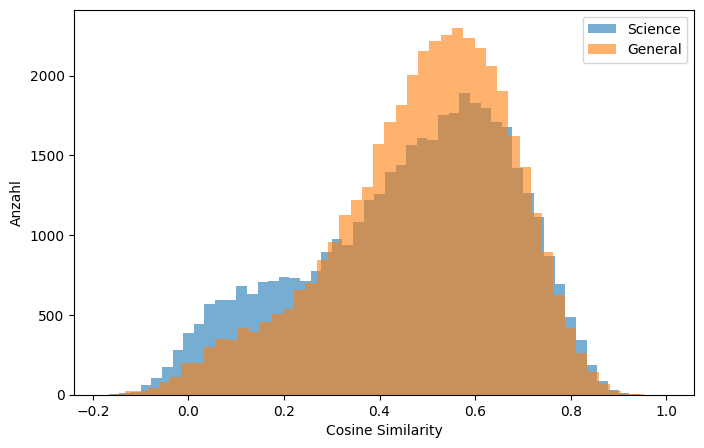

In [35]:

plt.figure(figsize=(8, 5))

plt.hist(science_similarity, bins=50, alpha=0.6, label="Science")
plt.hist(general_similarity, bins=50, alpha=0.6, label="General")

plt.xlabel("Cosine Similarity")
plt.ylabel("Anzahl")
plt.legend()

plt.show()

In [36]:

# --------------------------------------------------
# Embeddings speichern
# --------------------------------------------------
np.save("../data/checkpoints/science_content_embeddings.npy", science_content_embeddings)
np.save("../data/checkpoints/science_summary_embeddings.npy", science_summary_embeddings)

np.save("../data/checkpoints/general_content_embeddings.npy", general_content_embeddings)
np.save("../data/checkpoints/general_summary_embeddings.npy", general_summary_embeddings)

# --------------------------------------------------
# Cosine Similarities speichern
# --------------------------------------------------
np.save("../data/checkpoints/science_similarity.npy", science_similarity)
np.save("../data/checkpoints/general_similarity.npy", general_similarity)

# --------------------------------------------------
# DataFrame inklusive cosine_similarity speichern
# --------------------------------------------------
data_final.to_pickle("../data/checkpoints/checkpoint_similarity.pkl")

print("Alle Dateien wurden erfolgreich gespeichert.")

Alle Dateien wurden erfolgreich gespeichert.


In [38]:
# --------------------------------------------------
# Embeddings laden
# --------------------------------------------------
science_content_embeddings = np.load("../data/checkpoints/science_content_embeddings.npy")
science_summary_embeddings = np.load("../data/checkpoints/science_summary_embeddings.npy")

general_content_embeddings = np.load("../data/checkpoints/general_content_embeddings.npy")
general_summary_embeddings = np.load("../data/checkpoints/general_summary_embeddings.npy")

# --------------------------------------------------
# Cosine Similarities laden
# --------------------------------------------------
science_similarity = np.load("../data/checkpoints/science_similarity.npy")
general_similarity = np.load("../data/checkpoints/general_similarity.npy")

# --------------------------------------------------
# DataFrame laden
# --------------------------------------------------
data_final = pd.read_pickle("../data/checkpoints/checkpoint_similarity.pkl")

print("Alle Dateien wurden erfolgreich geladen.")

# Optional: Kontrolle
print(data_final.head())
print(science_content_embeddings.shape)
print(general_content_embeddings.shape)

Alle Dateien wurden erfolgreich geladen.
   Index          author                                               body  \
0     90    Occamsrazor1  Every basic ecology class teaches this. The id...   
1     91      Suddenfury  i was thinking about exactly this just yesterd...   
2    104    flutterbug32  One thing I have been told multiple times is t...   
3    226   champyonfiyah  I'll take a crack at this.  Starting with:    ...   
4    300  Destructor1701  The *apparent* size - which is a function of s...   

                                      normalizedBody  \
0  Every basic ecology class teaches this. The id...   
1  i was thinking about exactly this just yesterd...   
2  One thing I have been told multiple times is t...   
3  I'll take a crack at this.  Starting with:    ...   
4  The  apparent  size - which is a function of s...   

                                             content  content_len  \
0  Every basic ecology class teaches this. The id...          112   
1  i was 

In [39]:
data_final.columns
# science_similarity

Index(['Index', 'author', 'body', 'normalizedBody', 'content', 'content_len',
       'summary', 'summary_len', 'id', 'subreddit', 'subreddit_id', 'title',
       'is_science', 'cosine_similarity'],
      dtype='str')

Readability Metric

In [41]:
# readibilty scores
def compute_readability(text):
    """Compute multiple readability scores for a given text."""
    return {
        'flesch_reading_ease': textstat.flesch_reading_ease(text),
        'flesch_kincaid_grade': textstat.flesch_kincaid_grade(text),
        'gunning_fog': textstat.gunning_fog(text),
        'coleman_liau': textstat.coleman_liau_index(text)
    }

# Compute readability for content and summary separately
content_readability = data_final['content'].apply(compute_readability)
summary_readability = data_final['summary'].apply(compute_readability)

# Expand into separate columns with prefixes
content_readability_df = pd.DataFrame(content_readability.tolist()).add_prefix('content_')
summary_readability_df = pd.DataFrame(summary_readability.tolist()).add_prefix('summary_')

# Merge into main dataframe
data_final = pd.concat([data_final, content_readability_df, summary_readability_df], axis=1)

In [42]:
readability_metrics = ['flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'coleman_liau']

for metric in readability_metrics:
    data_final[f'delta_{metric}'] = (
        data_final[f'summary_{metric}'] - data_final[f'content_{metric}']
    )

cols_to_check = (
    [f'content_{m}' for m in readability_metrics] +
    [f'summary_{m}' for m in readability_metrics] +
    [f'delta_{m}' for m in readability_metrics]
)

data_final[cols_to_check].describe()

,content_flesch_reading_ease,content_flesch_kincaid_grade,content_gunning_fog,content_coleman_liau,summary_flesch_reading_ease,summary_flesch_kincaid_grade,summary_gunning_fog,summary_coleman_liau,delta_flesch_reading_ease,delta_flesch_kincaid_grade,delta_gunning_fog,delta_coleman_liau
count,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000,83664.000000
mean,63.607933,9.553847,11.920742,7.794756,66.991985,7.573064,9.809084,7.150960,3.384053,-1.980783,-2.111658,-0.643797
std,19.075162,5.668101,5.907513,3.708908,27.574636,5.000461,5.449044,6.685894,29.046244,6.777229,7.186368,6.230235
min,-1451.725000,-3.010000,0.800000,-21.900000,-1063.180000,-3.400000,0.400000,-39.600000,-1142.052857,-533.817619,-549.009524,-325.100000
25%,55.448428,7.046441,9.196764,6.020797,53.968963,4.608031,6.218182,4.709091,-9.674465,-4.562660,-5.114732,-2.689529
50%,65.979750,8.895238,11.224242,7.487780,69.277500,7.209524,9.200000,7.307692,3.377762,-1.671655,-1.835585,-0.265195
75%,74.435816,11.106944,13.657774,9.288601,82.829615,10.128572,12.678261,9.980645,16.673409,1.029218,1.199184,2.026004
max,120.205000,559.570000,593.600000,593.901754,121.220000,176.390000,184.800000,589.759091,1399.559286,157.802857,61.160711,336.484444


In [43]:
# Check extreme outliers
pd.set_option('display.max_colwidth', None)
print(data_final[data_final['content_flesch_kincaid_grade'] > 50][['content', 'content_flesch_kincaid_grade']].head(10))
pd.reset_option('display.max_colwidth')

In [44]:
# check for unusual values of flesch_kincaid_grade
print((data_final['content_flesch_kincaid_grade'] > 20).sum())
print((data_final['content_flesch_kincaid_grade'] > 30).sum())

1426
451


In [45]:
print((data_final['summary_flesch_kincaid_grade'] > 30).sum())
data_final[data_final['summary_flesch_kincaid_grade'] > 30][['summary', 'summary_flesch_kincaid_grade']].head(10)

243


,summary,summary_flesch_kincaid_grade
91,aftereffects,32.000000
234,impossible,32.000000
411,Disembowelment.,43.800000
454,Professional:yes Nonprofessional:no,50.090000
616,Stress=Cortisol=Sympathetic Nervous System act...,37.711429
1159,Pros- PA's practice=flexible- you're not locke...,57.756224
3041,excluding freak occurrences no you will cannot...,32.209859
3713,hypothetical.,43.800000
3829,regulations,32.000000
5864,Evolution.,32.000000


In [46]:
# check very short summaries
data_final[data_final['summary_len'] <= 3][['summary', 'summary_len']].sample(20, random_state=42)

,summary,summary_len
8606,Listen to OrbitalPete,3
25861,WTF? \n EDIT: formatting....,3
42042,lmao,1
67758,I'm so high.,3
44663,Mandatory summary/question!,2
56925,WALLOFTEXT,1
2773,don't overthink it.,3
34360,Babies. How?,2
3011,Sources?,1
3187,stfu.,1


Cleaning Data

In [47]:
# Store original count for reporting
n_before = len(data_final)

# 1. Remove duplicates
data_final = data_final.drop_duplicates(subset='content')

# 2. Filter implausible readability scores on content side (lists, markup artifacts)
data_final = data_final[data_final['content_flesch_kincaid_grade'] < 30]

# 3. Filter summaries that are too short to be meaningful
data_final = data_final[data_final['summary_len'] > 3]

# Report
n_after = len(data_final)
print(f"Removed {n_before - n_after} observations ({(n_before - n_after) / n_before * 100:.1f}%)")
print(f"Remaining: {n_after}")

#checkpoint
data_final.to_pickle("../data/checkpoints/checkpoint_aftercleaning.pkl")

Removed 4445 observations (5.3%)
Remaining: 79219


In [48]:
# check balance between categories
print(data_final['is_science'].value_counts())
print(data_final['is_science'].value_counts(normalize=True).round(3))

is_science
False    40017
True     39202
Name: count, dtype: int64
is_science
False    0.505
True     0.495
Name: proportion, dtype: float64


In [49]:
# check for urls
print(data_final['content'].str.contains(r'https?://\S+', regex=True).sum())
print(data_final['summary'].str.contains(r'https?://\S+', regex=True).sum())

0
0


In [50]:
# check th ratio of non-alphabetic characters
data_final['content_alpha_ratio'] = data_final['content'].apply(
    lambda x: sum(c.isalpha() for c in x) / len(x) if len(x) > 0 else 0
)
print(data_final['content_alpha_ratio'].describe())
print((data_final['content_alpha_ratio'] < 0.5).sum())

count    79219.000000
mean         0.773986
std          0.028132
min          0.191871
25%          0.763478
50%          0.776190
75%          0.789633
max          0.876957
Name: content_alpha_ratio, dtype: float64
49


In [51]:
# check for irrational content ratios
pd.set_option('display.max_colwidth', None)
print(data_final[data_final['content_alpha_ratio'] < 0.5][['content', 'content_alpha_ratio']])
pd.reset_option('display.max_colwidth')

In [52]:
data_final = data_final[data_final['content_alpha_ratio'] >= 0.5]
print(f"Remaining: {len(data_final)}")

Remaining: 79170


In [53]:
# check effect on cosine similarities
print("Science:")
print(data_final[data_final['is_science']]['cosine_similarity'].describe())

print("\nGeneral:")
print(data_final[~data_final['is_science']]['cosine_similarity'].describe())

Science:
count    39180.000000
mean         0.479244
std          0.202613
min         -0.166556
25%          0.349476
50%          0.510447
75%          0.633841
max          0.944736
Name: cosine_similarity, dtype: float64

General:
count    39990.000000
mean         0.498844
std          0.175399
min         -0.134836
25%          0.393109
50%          0.519837
75%          0.627010
max          0.943449
Name: cosine_similarity, dtype: float64


Compression Ratio (len of summary in relation to len of content)

In [54]:
# Compression ratio: how much shorter is the summary compared to the content?
data_final['compression_ratio'] = data_final['summary_len'] / data_final['content_len']

# Quick sanity check
print(data_final['compression_ratio'].describe())
print(f"\nValues above 1 (summary longer than content): {(data_final['compression_ratio'] > 1).sum()}")

count    79170.000000
mean         0.156782
std          0.155500
min          0.000836
25%          0.059275
50%          0.108108
75%          0.192308
max          0.996805
Name: compression_ratio, dtype: float64

Values above 1 (summary longer than content): 0


Profanity Metric

In [55]:
# Convert columns to string first
data_final['content'] = data_final['content'].astype(str)
data_final['summary'] = data_final['summary'].astype(str)
# Convert wordset to clean Python strings first
clean_wordset = [str(w) for w in profanity.CENSOR_WORDSET]

# Build pattern from clean strings
profanity_pattern = r'\b(' + '|'.join(re.escape(w) for w in clean_wordset) + r')\b'

# Vectorized check
data_final['content_profanity'] = data_final['content'].str.lower().str.contains(
    profanity_pattern, regex=True, na=False).astype(int)

data_final['summary_profanity'] = data_final['summary'].str.lower().str.contains(
    profanity_pattern, regex=True, na=False).astype(int)

print("Content profanity rate:", data_final['content_profanity'].mean().round(3))
print("Summary profanity rate:", data_final['summary_profanity'].mean().round(3))

C:\Users\ludwi\AppData\Local\Temp\ipykernel_20152\1304417574.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data_final['content_profanity'] = data_final['content'].str.lower().str.contains(
C:\Users\ludwi\AppData\Local\Temp\ipykernel_20152\1304417574.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data_final['summary_profanity'] = data_final['summary'].str.lower().str.contains(


Content profanity rate: 0.359
Summary profanity rate: 0.133


In [56]:
# change between content and summary
data_final['delta_profanity'] = data_final['summary_profanity'] - data_final['content_profanity']

# Compare Categories
print("Content profanity by category:")
print(data_final.groupby('is_science')['content_profanity'].mean().round(3))

print("\nSummary profanity by category:")
print(data_final.groupby('is_science')['summary_profanity'].mean().round(3))

print("\nDelta profanity by category:")
print(data_final.groupby('is_science')['delta_profanity'].mean().round(3))

Content profanity by category:
is_science
False    0.477
True     0.237
Name: content_profanity, dtype: float64

Summary profanity by category:
is_science
False    0.173
True     0.093
Name: summary_profanity, dtype: float64

Delta profanity by category:
is_science
False   -0.304
True    -0.144
Name: delta_profanity, dtype: float64


In [57]:
# Load the default wordlist
profanity.load_censor_words()

# Convert to readable strings
readable_wordlist = sorted([str(w) for w in profanity.CENSOR_WORDSET])
print(readable_wordlist)
print(f"\nNumber of words: {len(readable_wordlist)}")

['2 girls 1 cup', '4r5e', 'anal', 'anus', 'areole', 'arian', 'arrse', 'arse', 'arsehole', 'aryan', 'asanchez', 'ass', 'ass-fucker', 'assbang', 'assbanged', 'asses', 'assfuck', 'assfucker', 'assfukka', 'asshole', 'assmunch', 'asswhole', 'auto erotic', 'autoerotic', 'ballsack', 'bastard', 'bdsm', 'beastial', 'beastiality', 'bellend', 'bestial', 'bestiality', 'bimbo', 'bimbos', 'bitch', 'bitches', 'bitchin', 'bitching', 'blow job', 'blowjob', 'blowjobs', 'blue waffle', 'bondage', 'boner', 'boob', 'boobs', 'booobs', 'boooobs', 'booooobs', 'booooooobs', 'booty call', 'breasts', 'brown shower', 'brown showers', 'buceta', 'bukake', 'bukkake', 'bull shit', 'bullshit', 'busty', 'butthole', 'carpet muncher', 'cawk', 'chink', 'cipa', 'clit', 'clitoris', 'clits', 'cnut', 'cock', 'cockface', 'cockhead', 'cockmunch', 'cockmuncher', 'cocks', 'cocksuck', 'cocksucked', 'cocksucker', 'cocksucking', 'cocksucks', 'cokmuncher', 'coon', 'cow girl', 'cow girls', 'cowgirl', 'cowgirls', 'crap', 'crotch', 'cum'

Sentiment and Subjectivity

In [58]:
# Sentiment Analysis (VADER) and Subjectivity (TextBlob)
analyzer = SentimentIntensityAnalyzer()

# VADER sentiment for content and summary
data_final['content_sentiment'] = data_final['content'].apply(
    lambda x: analyzer.polarity_scores(x)['compound'])

data_final['summary_sentiment'] = data_final['summary'].apply(
    lambda x: analyzer.polarity_scores(x)['compound'])

# TextBlob subjectivity for content and summary
data_final['content_subjectivity'] = data_final['content'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity)

data_final['summary_subjectivity'] = data_final['summary'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity)

# Delta variants
data_final['delta_sentiment'] = data_final['summary_sentiment'] - data_final['content_sentiment']
data_final['delta_subjectivity'] = data_final['summary_subjectivity'] - data_final['content_subjectivity']

# Quick overview
print(data_final[['content_sentiment', 'summary_sentiment', 
                   'content_subjectivity', 'summary_subjectivity']].describe().round(3))

       content_sentiment  summary_sentiment  content_subjectivity  \
count          79170.000          79170.000             79170.000   
mean               0.358              0.119                 0.480   
std                0.730              0.502                 0.107   
min               -1.000             -1.000                 0.000   
25%               -0.300             -0.241                 0.422   
50%                0.760              0.000                 0.481   
75%                0.963              0.527                 0.539   
max                1.000              1.000                 1.000   

       summary_subjectivity  
count             79170.000  
mean                  0.418  
std                   0.277  
min                   0.000  
25%                   0.200  
50%                   0.450  
75%                   0.600  
max                   1.000  


In [59]:
# check categories
print("Content sentiment by category:")
print(data_final.groupby('is_science')['content_sentiment'].mean().round(3))

print("\nSummary sentiment by category:")
print(data_final.groupby('is_science')['summary_sentiment'].mean().round(3))

print("Content subjectivity by category:")
print(data_final.groupby('is_science')['content_subjectivity'].mean().round(3))

print("\nSummary subjectivity by category:")
print(data_final.groupby('is_science')['summary_subjectivity'].mean().round(3))

print("\nDelta sentiment by category:")
print(data_final.groupby('is_science')['delta_sentiment'].mean().round(3))

print("\nDelta subjectivity by category:")
print(data_final.groupby('is_science')['delta_subjectivity'].mean().round(3))

Content sentiment by category:
is_science
False    0.370
True     0.346
Name: content_sentiment, dtype: float64

Summary sentiment by category:
is_science
False    0.128
True     0.110
Name: summary_sentiment, dtype: float64
Content subjectivity by category:
is_science
False    0.488
True     0.471
Name: content_subjectivity, dtype: float64

Summary subjectivity by category:
is_science
False    0.425
True     0.411
Name: summary_subjectivity, dtype: float64

Delta sentiment by category:
is_science
False   -0.242
True    -0.235
Name: delta_sentiment, dtype: float64

Delta subjectivity by category:
is_science
False   -0.063
True    -0.060
Name: delta_subjectivity, dtype: float64


Entity Retention Rate

In [60]:
# entity retention rate with spacy
# Hier sollte noch erwähnt sein, dass man davor im terminal das englische LM runterladen muss
# !python -m spacy download en_core_web_sm

nlp = spacy.load('en_core_web_sm')

def entity_retention_rate(content, summary):
    # Extract entities from content and summary
    content_entities = set(ent.text.lower() for ent in nlp(content).ents)
    summary_entities = set(ent.text.lower() for ent in nlp(summary).ents)
    
    # If no entities in content, return NaN
    if len(content_entities) == 0:
        return None
    
    # Proportion of content entities retained in summary
    retained = content_entities.intersection(summary_entities)
    return len(retained) / len(content_entities)

data_final['entity_retention_rate'] = data_final.apply(
    lambda row: entity_retention_rate(row['content'], row['summary']), axis=1)

# Overview
print(data_final['entity_retention_rate'].describe().round(3))
print(f"\nComments with no entities (NaN): {data_final['entity_retention_rate'].isna().sum()}")

# By category
print("\nEntity retention rate by category:")
print(data_final.groupby('is_science')['entity_retention_rate'].mean().round(3))

count    73886.000
mean         0.051
std          0.125
min          0.000
25%          0.000
50%          0.000
75%          0.034
max          1.000
Name: entity_retention_rate, dtype: float64

Comments with no entities (NaN): 5284

Entity retention rate by category:
is_science
False    0.050
True     0.051
Name: entity_retention_rate, dtype: float64


In [61]:
# handle missing values due to no entities in content-column
data_final['entity_retention_rate'] = data_final['entity_retention_rate'].fillna(
    data_final['entity_retention_rate'].median()
)

In [ ]:
# Save as pickle (recommended - preserves all dtypes)
data_final.to_pickle('../data/data_final_features.pkl')


# Verify
print(f"Saved {len(data_final)} rows and {len(data_final.columns)} columns")
print("\nColumns saved:")
print(data_final.columns.tolist())

                              content_flesch_reading_ease  \
content_flesch_reading_ease                          1.00   
content_flesch_kincaid_grade                        -0.90   
content_gunning_fog                                 -0.89   
content_coleman_liau                                -0.85   

                              content_flesch_kincaid_grade  \
content_flesch_reading_ease                          -0.90   
content_flesch_kincaid_grade                          1.00   
content_gunning_fog                                   0.98   
content_coleman_liau                                  0.62   

                              content_gunning_fog  content_coleman_liau  
content_flesch_reading_ease                 -0.89                 -0.85  
content_flesch_kincaid_grade                 0.98                  0.62  
content_gunning_fog                          1.00                  0.62  
content_coleman_liau                         0.62                  1.00  


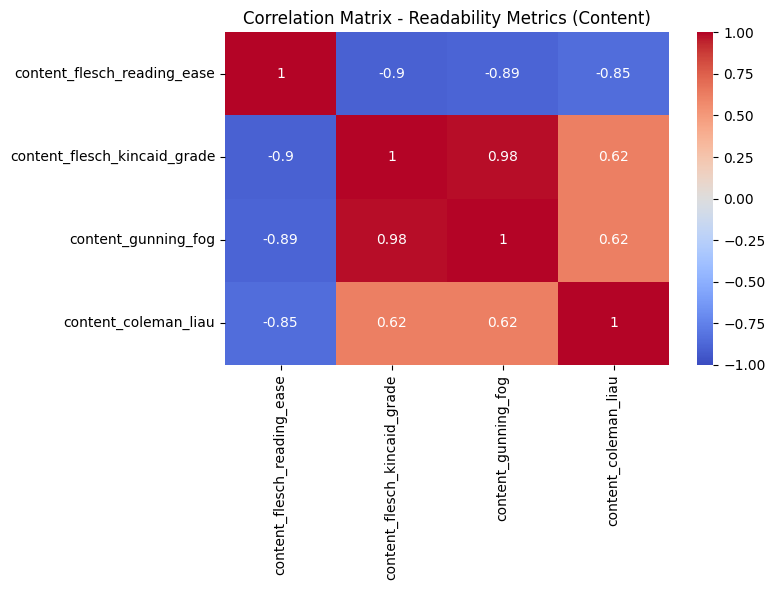

In [62]:
# check readability features again and select one

readability_cols = [
    'content_flesch_reading_ease', 'content_flesch_kincaid_grade',
    'content_gunning_fog', 'content_coleman_liau'
]

corr_matrix_readability = data_final[readability_cols].corr().round(2)
print(corr_matrix_readability)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_readability, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Readability Metrics (Content)')
plt.tight_layout()
plt.show()

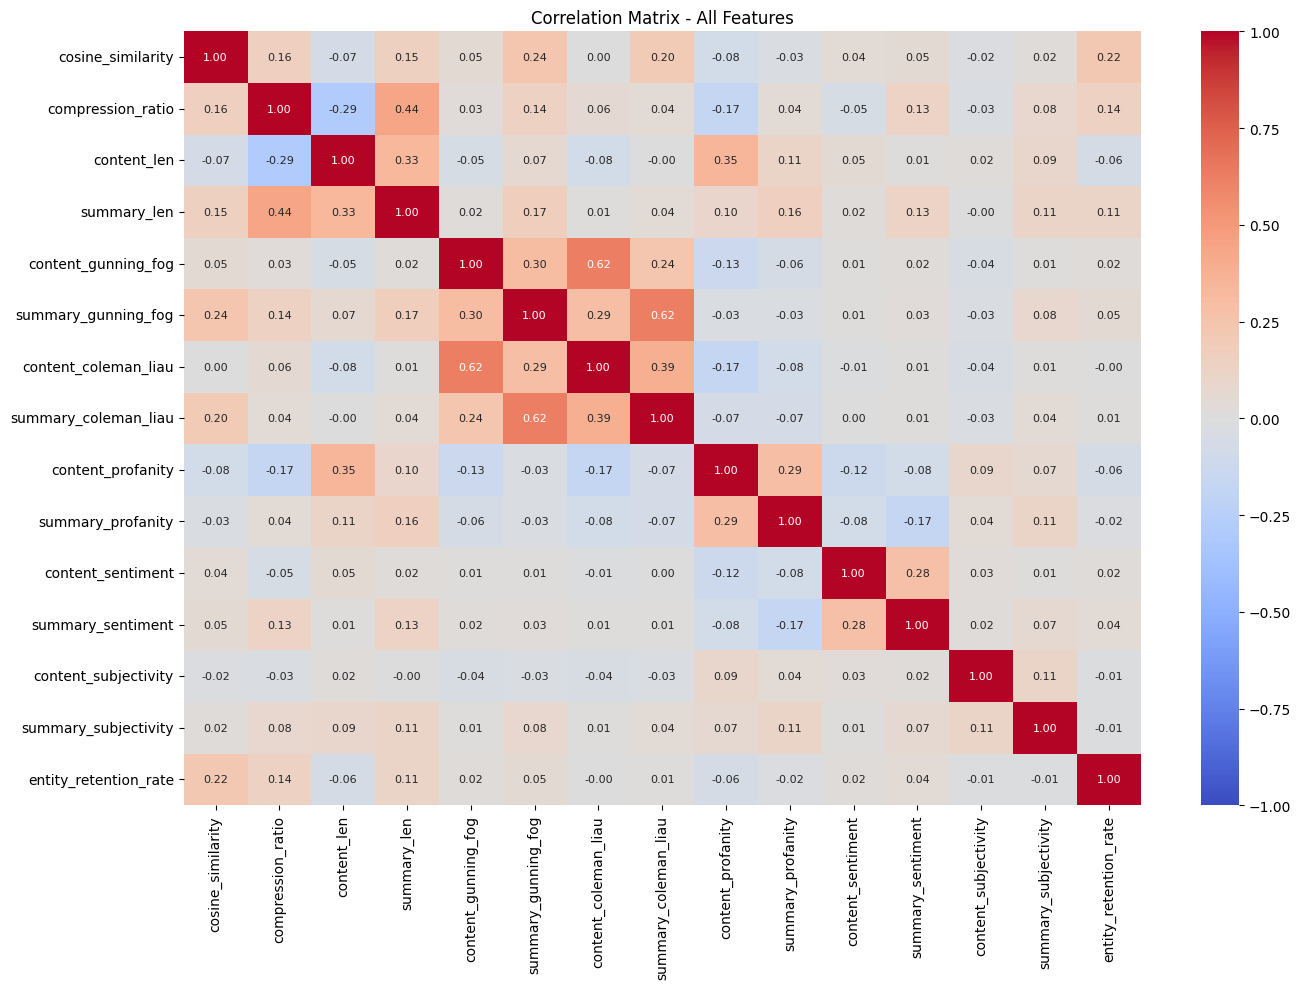

,cosine_similarity,compression_ratio,content_len,summary_len,content_gunning_fog,summary_gunning_fog,content_coleman_liau,summary_coleman_liau,content_profanity,summary_profanity,content_sentiment,summary_sentiment,content_subjectivity,summary_subjectivity,entity_retention_rate
cosine_similarity,1.00,0.16,-0.07,0.15,0.05,0.24,0.00,0.20,-0.08,-0.03,0.04,0.05,-0.02,0.02,0.22
compression_ratio,0.16,1.00,-0.29,0.44,0.03,0.14,0.06,0.04,-0.17,0.04,-0.05,0.13,-0.03,0.08,0.14
content_len,-0.07,-0.29,1.00,0.33,-0.05,0.07,-0.08,-0.00,0.35,0.11,0.05,0.01,0.02,0.09,-0.06
summary_len,0.15,0.44,0.33,1.00,0.02,0.17,0.01,0.04,0.10,0.16,0.02,0.13,-0.00,0.11,0.11
content_gunning_fog,0.05,0.03,-0.05,0.02,1.00,0.30,0.62,0.24,-0.13,-0.06,0.01,0.02,-0.04,0.01,0.02
summary_gunning_fog,0.24,0.14,0.07,0.17,0.30,1.00,0.29,0.62,-0.03,-0.03,0.01,0.03,-0.03,0.08,0.05
content_coleman_liau,0.00,0.06,-0.08,0.01,0.62,0.29,1.00,0.39,-0.17,-0.08,-0.01,0.01,-0.04,0.01,-0.00
summary_coleman_liau,0.20,0.04,-0.00,0.04,0.24,0.62,0.39,1.00,-0.07,-0.07,0.00,0.01,-0.03,0.04,0.01
content_profanity,-0.08,-0.17,0.35,0.10,-0.13,-0.03,-0.17,-0.07,1.00,0.29,-0.12,-0.08,0.09,0.07,-0.06
summary_profanity,-0.03,0.04,0.11,0.16,-0.06,-0.03,-0.08,-0.07,0.29,1.00,-0.08,-0.17,0.04,0.11,-0.02


In [63]:
# check collinearity of other features
feature_cols = [
    'cosine_similarity', 'compression_ratio', 'content_len', 'summary_len',
    'content_gunning_fog', 'summary_gunning_fog',
    'content_coleman_liau', 'summary_coleman_liau',
    'content_profanity', 'summary_profanity',
    'content_sentiment', 'summary_sentiment',
    'content_subjectivity', 'summary_subjectivity',
    'entity_retention_rate'
]

corr_matrix = data_final[feature_cols].corr().round(2)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation Matrix - All Features')
plt.tight_layout()
plt.show()
corr_matrix

Logistic Regression based on summary features and cosine similarity and entity retention rate and compression ratio

In [64]:
# feature preparation for logreg
feature_cols_model1 = [
    'cosine_similarity',
    'compression_ratio',
    'summary_gunning_fog',
    'summary_coleman_liau',
    'summary_profanity',
    'summary_sentiment',
    'summary_subjectivity',
    'entity_retention_rate'
]

X = data_final[feature_cols_model1].values
y = data_final['is_science'].astype(int).values

# Pipeline standardizing features and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Stratified 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print(f"Accuracy:  {scores.mean():.3f} (+/- {scores.std():.3f})")
print(f"F1 Score:  {f1_scores.mean():.3f} (+/- {f1_scores.std():.3f})")
print(f"ROC-AUC:   {roc_scores.mean():.3f} (+/- {roc_scores.std():.3f})")

Accuracy:  0.615 (+/- 0.005)
F1 Score:  0.605 (+/- 0.004)
ROC-AUC:   0.656 (+/- 0.006)


In [65]:
# Fit pipeline on full data to inspect coefficients
pipeline.fit(X, y)

# Extract coefficients
coefficients = pipeline.named_steps['clf'].coef_[0]
feature_names = feature_cols_model1

# Create summary table
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print(coef_df.round(3))

                 feature  coefficient  abs_coefficient
3   summary_coleman_liau        0.358            0.358
0      cosine_similarity       -0.252            0.252
4      summary_profanity       -0.251            0.251
1      compression_ratio        0.176            0.176
2    summary_gunning_fog        0.169            0.169
5      summary_sentiment       -0.092            0.092
6   summary_subjectivity       -0.057            0.057
7  entity_retention_rate       -0.011            0.011


In [66]:
# logreg table
X_scaled = pipeline.named_steps['scaler'].transform(X)
X_with_const = sm.add_constant(X_scaled)

logit_model = sm.Logit(y, X_with_const)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656432
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                79170
Model:                          Logit   Df Residuals:                    79161
Method:                           MLE   Df Model:                            8
Date:                 Mi, 17 Jun 2026   Pseudo R-squ.:                 0.05290
Time:                        19:00:23   Log-Likelihood:                -51970.
converged:                       True   LL-Null:                       -54872.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0188      0.007     -2.542      0.011      -0.033      -0.004
x1            -0.2517      0.

Model including also the content versions of the features

In [67]:
# model 2, also adding the "content"-versions of features
feature_cols_model2 = [
    'cosine_similarity',
    'compression_ratio',
    'content_gunning_fog',
    'summary_gunning_fog',
    'content_coleman_liau',
    'summary_coleman_liau',
    'content_profanity',
    'summary_profanity',
    'content_sentiment',
    'summary_sentiment',
    'content_subjectivity',
    'summary_subjectivity',
    'entity_retention_rate'
]

X2 = data_final[feature_cols_model2].values
y = data_final['is_science'].astype(int).values

pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores2 = cross_val_score(pipeline2, X2, y, cv=cv, scoring='accuracy')
f1_scores2 = cross_val_score(pipeline2, X2, y, cv=cv, scoring='f1')
roc_scores2 = cross_val_score(pipeline2, X2, y, cv=cv, scoring='roc_auc')

print("Model 2 - Content + Summary Features")
print(f"Accuracy:  {scores2.mean():.3f} (+/- {scores2.std():.3f})")
print(f"F1 Score:  {f1_scores2.mean():.3f} (+/- {f1_scores2.std():.3f})")
print(f"ROC-AUC:   {roc_scores2.mean():.3f} (+/- {roc_scores2.std():.3f})")

print("\nModel 1 - Summary Features only (for comparison)")
print(f"Accuracy:  {scores.mean():.3f} (+/- {scores.std():.3f})")
print(f"F1 Score:  {f1_scores.mean():.3f} (+/- {f1_scores.std():.3f})")
print(f"ROC-AUC:   {roc_scores.mean():.3f} (+/- {roc_scores.std():.3f})")

Model 2 - Content + Summary Features
Accuracy:  0.730 (+/- 0.003)
F1 Score:  0.722 (+/- 0.003)
ROC-AUC:   0.800 (+/- 0.003)

Model 1 - Summary Features only (for comparison)
Accuracy:  0.615 (+/- 0.005)
F1 Score:  0.605 (+/- 0.004)
ROC-AUC:   0.656 (+/- 0.006)


In [68]:
# linear regression on cosine similarity
feature_cols_regression = [
    'compression_ratio',
    'summary_gunning_fog',
    'summary_coleman_liau',
    'summary_profanity',
    'summary_sentiment',
    'summary_subjectivity',
    'entity_retention_rate',
    'is_science'
]

X_reg = data_final[feature_cols_regression].values
y_reg = data_final['cosine_similarity'].values

# Cross-validated R²
pipeline_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(pipeline_reg, X_reg, y_reg, cv=cv_reg, scoring='r2')

print(f"Cross-validated R²: {r2_scores.mean():.3f} (+/- {r2_scores.std():.3f})")

# Statsmodels for coefficients and p-values
X_scaled_reg = StandardScaler().fit_transform(X_reg)
X_with_const = sm.add_constant(X_scaled_reg)

ols_model = sm.OLS(y_reg, X_with_const)
result = sm.OLS(y_reg, X_with_const).fit()
print(result.summary())

Cross-validated R²: 0.129 (+/- 0.004)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     1469.
Date:                 Mi, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:00:24   Log-Likelihood:                 24785.
No. Observations:               79170   AIC:                        -4.955e+04
Df Residuals:                   79161   BIC:                        -4.947e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

In [ ]:
# data_final_check = pd.read_pickle('../data/data_final_features.pkl')
# data_final_check.head()

,Index,author,body,normalizedBody,content,content_len,summary,summary_len,id,subreddit,...,content_profanity,summary_profanity,delta_profanity,content_sentiment,summary_sentiment,content_subjectivity,summary_subjectivity,delta_sentiment,delta_subjectivity,entity_retention_rate
0,90,Occamsrazor1,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,112,We need to stop being such selfish bastards,8,c6hj5o3,science,...,0,0,0,0.2040,-0.8519,0.397338,0.75,-1.0559,0.352662,0.0
1,91,Suddenfury,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,148,why are the fishfarm industry so small scale?,8,c6hml12,science,...,0,0,0,0.6075,0.0000,0.480427,0.40,-0.6075,-0.080427,0.0
2,104,flutterbug32,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,270,who you know is more helpful sometimes than wh...,11,c6rgfy8,ecology,...,0,0,0,0.9932,0.4754,0.482919,0.50,-0.5178,0.017081,0.0
3,226,champyonfiyah,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,213,Yes you can do that with an arduino.,8,c6v4cup,arduino,...,0,0,0,0.9910,0.4019,0.542587,0.00,-0.5891,-0.542587,0.0
4,300,Destructor1701,The *apparent* size - which is a function of s...,The apparent size - which is a function of s...,The apparent size - which is a function of s...,97,Distance matters only as part of the function ...,24,c71qcs8,space,...,0,0,0,0.2433,0.0258,0.550694,0.45,-0.2175,-0.100694,0.0
